Wir arbeiten im Folgenden mit dem USPS (United States Postal Service) Datensatz, der 16x16 Grauwertbilder von handgeschriebenen Ziffern (0-9) enthält.

![title](https://git-disl.github.io/GTDLBench/figures/usps.png)

1.) Laden Sie die Datendatei usps_data.hdf5 file von moodle und importieren Sie die Daten in python. Passen Sie den Pfad zu den Daten entsprechend an!


In [2]:
import h5py
import numpy as np

# Load the USPS data
f = h5py.File("../doc/usps_data.hdf5", 'r') # adapt path
trainX = np.array(f.get('trainX'))
trainY = np.array(f.get('trainY'))
testX = np.array(f.get('testX'))
testY = np.array(f.get('testY'))
f.close()

2.) Trainieren Sie einen Decision Tree auf den Trainigsdaten und führen Sie eine Klassifikation der Testdaten durch. Sie können hierzu die in scikit-learn verfügbare Implementierung nutzen. Die scikit-learn Doku finden Sie hier: https://scikit-learn.org/stable/user_guide.html:

In [3]:
# TODO

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# training
# Wir können auch noch mit der max_depth herumspielen
model = DecisionTreeClassifier(random_state=2406)   # random_state found through brute-force search, see below
model = model.fit(trainX, trainY)

# prediction
predictedY = model.predict(testX)

# tree.plot_tree(model, max_depth=2, filled=True)


Bewerten Sie die Güte des Klassifikators mittels seiner Vorhersagegenauigkeit. Berechnen Sie dazu den Anteil der korrekt klassifizierten Testbilder.

In [4]:
from sklearn.metrics import accuracy_score

# Accuracy
accuracy = accuracy_score(testY, predictedY)
print(f"Accuracy: {accuracy}")

Accuracy: 0.866


Wie interpretieren Sie das Ergebnis? Was passiert, wenn Sie eine Vorhersage auf den Trainingsdaten machen? 

Was passiert, wenn Sie eine Vorhersage auf den Trainingsdaten machen? Welchen Effekt beobachten Sie?

In [5]:
predictedY_traindata = model.predict(trainX)
accuracy = accuracy_score(trainY, predictedY_traindata)
...
print(f"Accuracy on training data: {accuracy}")

Accuracy on training data: 1.0


**Beobachtung**: Wir bekommen eine Accuracy von 100%, da wir einen sehr tiefen Baum generieren da overfittet.


Nun wenden wir folgenden Vorverarbeitungsschritt an. Betrachten Sie den Code und führen Sie anschließend erneut ein Klassifikatortraining und eine Vorhersage durch. Hat sich die Güte verändert?

In [6]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def preprocessData(dataIn, sigma=1):
    dataOut = np.zeros(dataIn.shape)
    len = np.sqrt(dataIn.shape[1]).astype(np.int64)
    for i in range(0, dataIn.shape[0]):
        img = np.reshape(dataIn[i, :], [len, len]);
        img_filtered = gaussian_filter(img, sigma)
        dataOut[i, :] = np.reshape(img_filtered, [1, len*len]);       
    return dataOut

Das ist ein Klassischer Gaussian Blur um die Noise von den Daten zu reduzieren.

Accuracy is: 0.894


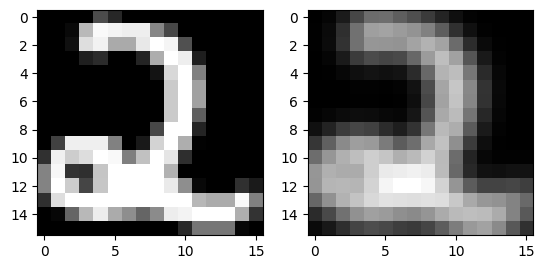

In [7]:
trainX_processed = preprocessData(trainX, 1)
testX_processed  = preprocessData(testX, 1)

# plot data example
fig, axs = plt.subplots(1,2)
axs[0].imshow(trainX[1000,:].reshape(16,16).transpose(),cmap='gray')
axs[1].imshow(trainX_processed[1000,:].reshape(16,16).transpose(),cmap='gray')

# train
model = DecisionTreeClassifier(random_state=3092)   # random_state found through brute-force search, see below
model = model.fit(trainX_processed, trainY)

# predict
predictedY = model.predict(testX_processed)

# ...accuracy
accuracy = accuracy_score(testY, predictedY)
print(f"Accuracy is: {accuracy}")

In [8]:
best_accuracy = 0
best_random_state = None
for i in range(10):
    # state = randInt()
    state = np.random.randint(0, 10000)
    model = DecisionTreeClassifier(random_state=state, max_depth=10)
    model = model.fit(trainX_processed, trainY)

    # prediction
    predictedY = model.predict(testX_processed)

    # Accuracy
    accuracy = accuracy_score(testY, predictedY)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_random_state = state
        print(f"New best accuracy: {best_accuracy} with random_state={best_random_state}")

New best accuracy: 0.871 with random_state=303
New best accuracy: 0.875 with random_state=87


KeyboardInterrupt: 

Bonus: Kleines Widget zum Selbermalen. Zunächst trainieren wir den Standard Decision Tree, dann bauen wir die entsprechenden Widgets.

In [10]:
dtree = DecisionTreeClassifier(criterion="gini", max_depth=10)
dtree.fit(trainX, trainY)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [11]:
def classify_test(test):
    test_digit_fixed = np.asarray(test).reshape(16, 16).T.reshape(1, 256)
    print(f"classified as: {dtree.predict(test_digit_fixed)}")
    

In [12]:
# Bridge: empfängt den 1x256-Array (0..1) und ruft classify_test(test).
# Alle Prints gehen in p16_log (das in Zelle B angezeigt wird).

import json, numpy as np, ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display

# Unsichtbares Bridge-Widget (muss angezeigt werden, damit JS es findet)
p16_store = widgets.Textarea(value='', layout=Layout(display='none'))
p16_store.add_class('p16-bridge')
display(p16_store)

# Log-Output (anzeigen wir erst in Zelle B)
p16_log = widgets.Output(layout=Layout(border='1px solid #ddd',
                                       max_height='180px',
                                       overflow='auto'))

def _on_store_change(change):
    if change['name'] != 'value' or not change['new']:
        return
    with p16_log:  # Alles hier landet später unter dem Painter
        try:
            payload = json.loads(change['new'])
            flat = payload['flat'] if isinstance(payload, dict) else payload
            # Zeilenweise 1x256; wenn du spaltenweise brauchst, mach es in classify_test selbst
            test = np.array(flat, dtype=float).reshape(1, 256)
            print(f"[Bridge] Empfangen (len={len(flat)})")

            try:
                res = classify_test(test)   # deine Funktion
                if res is not None:
                    print("classify_test return:", res)
            except NameError:
                print("Fehler: classify_test(test) ist nicht definiert.")
            except Exception as e:
                print("Fehler in classify_test(test):", e)

        except Exception as e:
            print("Bridge-Fehler:", e)

p16_store.observe(_on_store_change, names='value')


Textarea(value='', layout=Layout(display='none'), _dom_classes=('p16-bridge',))

In [13]:
from IPython.display import display, HTML
display(HTML(r"""
<div data-p16-container style="display:inline-flex;flex-direction:column;gap:8px;
     font-family:system-ui,Segoe UI,Roboto,Arial,sans-serif">
  <canvas class="cv" width="320" height="320"
          style="background:#000; image-rendering:pixelated; border:1px solid #444;
                 display:block; cursor:crosshair; touch-action:none"></canvas>
  <div style="display:flex; gap:8px">
    <button class="clear"    style="height:32px;padding:0 10px">Clear</button>
    <button class="classify" style="height:32px;padding:0 10px">Classify</button>
  </div>
  <div class="hint"   style="font-size:12px;color:#666">Pinsel: [[0,1,0],[1,2,1],[0,1,0]] / 6 (additiv, 0..1)</div>
  <div class="status" style="height:1.2em; font-size:12px; color:#666;"></div>
</div>

<script>
(function(){
  const root = document.currentScript.previousElementSibling;
  const cv   = root.querySelector('.cv');
  const btnC = root.querySelector('.clear');
  const btnX = root.querySelector('.classify');
  const stat = root.querySelector('.status');

  const N=16, CELL=20;
  const ctx = cv.getContext('2d', {alpha:false});
  ctx.imageSmoothingEnabled = false;

  // Bilddaten 0..1
  const data = Array.from({length:N}, ()=>Array(N).fill(0));

  // Kernel: [[0,1,0],[1,6,1],[0,1,0]] / 10
  const K = [[0,1/10,0],[1/10,6/10,1/10],[0,1/10,0]];
  const HALF = 1;
  const clamp01 = x => x<0?0:(x>1?1:x);

  function drawCell(r,c){
    const v = clamp01(data[r][c]);
    const g = Math.round(v*255);
    ctx.fillStyle = v>0 ? `rgb(${g},${g},${g})` : "#000";
    ctx.fillRect(c*CELL, r*CELL, CELL, CELL);
  }
  function redraw(){
    ctx.fillStyle="#000"; ctx.fillRect(0,0,cv.width,cv.height);
    for(let r=0;r<N;r++) for(let c=0;c<N;c++) if(data[r][c]>0) drawCell(r,c);
  }
  function stamp(r0,c0){
    for(let dr=-HALF; dr<=HALF; dr++){
      for(let dc=-HALF; dc<=HALF; dc++){
        const w = K[dr+HALF][dc+HALF]; if (w<=0) continue;
        const r=r0+dr, c=c0+dc;
        if (r>=0 && r<N && c>=0 && c<N){
          data[r][c] = clamp01(data[r][c] + w);
          drawCell(r,c);
        }
      }
    }
  }
  function posToCellXY(x,y){
    const rect = cv.getBoundingClientRect();
    const c = Math.floor((x-rect.left)  / (rect.width  / N));
    const r = Math.floor((y-rect.top)   / (rect.height / N));
    return {r,c};
  }
  function drawBetween(r1,c1,r2,c2){
    const steps = Math.max(Math.abs(r2-r1), Math.abs(c2-c1));
    for(let i=0;i<=steps;i++){
      const r = Math.round(r1 + (r2-r1)*i/Math.max(1,steps));
      const c = Math.round(c1 + (c2-c1)*i/Math.max(1,steps));
      stamp(r,c);
    }
  }

  // Interaktion
  let drawing=false, prev=null;
  cv.addEventListener('mousedown', e=>{
    e.preventDefault();
    drawing=true; const {r,c}=posToCellXY(e.clientX,e.clientY);
    stamp(r,c); prev={r,c};
  }, {passive:false});
  window.addEventListener('mouseup', ()=>{ drawing=false; prev=null; });
  cv.addEventListener('mouseleave', ()=>{ drawing=false; prev=null; });
  cv.addEventListener('mousemove', e=>{
    if(!drawing) return;
    e.preventDefault();
    const {r,c}=posToCellXY(e.clientX,e.clientY);
    if(!prev){ stamp(r,c); prev={r,c}; return; }
    if(r!==prev.r || c!==prev.c){ drawBetween(prev.r,prev.c,r,c); prev={r,c}; }
  }, {passive:false});

  // Touch
  cv.addEventListener('touchstart', e=>{
    e.preventDefault();
    const t=e.touches[0]; if(!t) return;
    drawing=true; const {r,c}=posToCellXY(t.clientX,t.clientY);
    stamp(r,c); prev={r,c};
  }, {passive:false});
  cv.addEventListener('touchmove', e=>{
    if(!drawing) return;
    e.preventDefault();
    const t=e.touches[0]; if(!t) return;
    const {r,c}=posToCellXY(t.clientX,t.clientY);
    if(!prev){ stamp(r,c); prev={r,c}; return; }
    if(r!==prev.r || c!==prev.c){ drawBetween(prev.r,prev.c,r,c); prev={r,c}; }
  }, {passive:false});
  cv.addEventListener('touchend', ()=>{ drawing=false; prev=null; }, {passive:false});
  cv.addEventListener('touchcancel', ()=>{ drawing=false; prev=null; }, {passive:false});

  // Clear
  btnC.addEventListener('click', ()=>{
    for(let r=0;r<N;r++) data[r].fill(0);
    redraw(); stat.textContent="Canvas gelöscht.";
  });

  // Classify → Bridge schreiben (mit Nonce, damit Value immer "neu" ist)
  btnX.addEventListener('click', ()=>{
    const flat=[]; for(let r=0;r<N;r++) for(let c=0;c<N;c++) flat.push(+data[r][c].toFixed(6));
    const payload = { flat: flat, nonce: Date.now() };
    const bridgeRoot = document.querySelector('.p16-bridge');
    const ta = bridgeRoot ? bridgeRoot.querySelector('textarea') : null;
    if (ta){
      ta.value = JSON.stringify(payload);
      ta.dispatchEvent(new Event('input',  {bubbles:true}));
      ta.dispatchEvent(new Event('change', {bubbles:true}));
      stat.textContent = "Array → classify_test(test). Ausgabe unten.";
    } else {
      stat.textContent = "Bridge-Widget nicht gefunden. Bitte Zelle A zuerst ausführen.";
    }
  });

  redraw();
})();
</script>
"""))

# ← direkt unter dem Painter anzeigen:
display(p16_log)


Output(layout=Layout(border_bottom='1px solid #ddd', border_left='1px solid #ddd', border_right='1px solid #dd…

...nicht perfekt, aber es klappt einigermaßen. Dass es manches mal nicht funktioniert, liegt vermutlich daran, dass die hier gezeichneten Ziffern aus einer anderen Verteilung kommen, also z.B. etwas mehr oder weniger geglättet sind als die Originaldaten.

3.) Trainieren Sie nun einen Random Forest Klassifikator und trainieren und testen Sie ihn auf den Daten. Verwenden Sie dafür die Implementierung RandomForestClassifier aus scikit learn.

Nutzen Sie hierfür die Funktionen
* model.fit()
* model.predict_proba() bzw. model.predict()

Verwenden Sie zunächst die Optionen

* 100 Bäume
* √𝑛𝑢𝑚𝐹𝑒𝑎𝑡𝑢𝑟𝑒𝑠 Features pro Knoten
* Berechnen Sie die Feature Imprtance



In [43]:
# training
from sklearn.ensemble import RandomForestClassifier

#train with 100 trees
model = RandomForestClassifier(n_estimators=100, max_features='sqrt', criterion='gini')
model = model.fit(trainX_processed, trainY)

c:\Users\moritz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


4) Testen Sie den Klassifikator auf den Testdaten mit "harten" und "soften" Klassenzuordnungen.

* Welche Vorhersagegenauigkeit erhalten Sie?
* Visualisieren Sie die Feature Importance!

Accuracy is: 0.964
Feature importances: [0.00081129 0.0011742  0.00126436 0.00116956 0.0014515  0.0025294
 0.00207082 0.00384188 0.00398271 0.0027234 ]


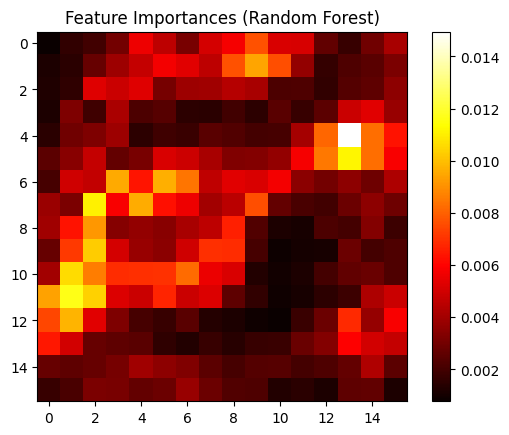

In [44]:
# testing
predY_probs = model.predict_proba(testX_processed)
predY = model.predict(testX_processed)

# ...accuracy
accuracy = np.sum(predY==testY.flatten())/testY.shape[0]
print(f"Accuracy is: {accuracy}")

# feature importances
feature_importances = model.feature_importances_
print(f"Feature importances: {feature_importances[:10]}")

# plot as image 16x16
plt.imshow(feature_importances.reshape(16,16).transpose(), cmap='hot')
plt.colorbar()
plt.title("Feature Importances (Random Forest)")
plt.show()

Untersuchen Sie ein Beispielbild, bei dem die Klassifikation fehlschlägt!

Indices where prediction and ground truth do not match:
[110 143 146 158 163 184 210 216 249 264]


Text(0.5, 1.0, '(pred=5.0, true=5)')

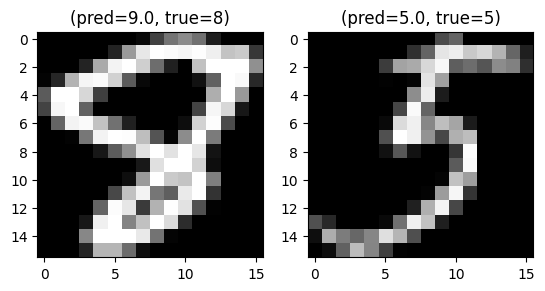

In [37]:
# TODO
print("Indices where prediction and ground truth do not match:")

match_mask = predY != testY.flatten()
mismatches = np.where(match_mask)[0]
matches = np.where(~match_mask)[0]

print(mismatches[:10])
# ...example classification where it does work
# plot data example
fig, axs = plt.subplots(1,2)
random_mismatch_index = np.random.randint(0, len(mismatches))
axs[0].imshow(testX[mismatches[random_mismatch_index],:].reshape(16,16).transpose(),cmap='gray')
axs[0].set_title(f"(pred={predY[mismatches[random_mismatch_index]]}, true={testY[mismatches[random_mismatch_index],0]})")

# ...example classification where it does not work (reason: 90° rotated "0")
random_match_index = np.random.randint(0, len(matches))
axs[1].imshow(testX[matches[random_match_index],:].reshape(16,16).transpose(),cmap='gray')
axs[1].set_title(f"(pred={predY[matches[random_match_index]]}, true={testY[matches[random_match_index],0]})")